# VAR Multivariate Time Series Analysis
## Air Quality, Electricity & Industrial Production (Malaysia 2018–2022)

**Models:**
1. VAR 1 — Car Registrations + Electricity Local → NO₂
2. VAR 2 — IPI Index + Electricity Local → SO₂
3. VAR 3 (Optional) — NO₂ → PM2.5

**Outputs:** IRF, FEVD, Granger Causality, Durbin-Watson diagnostics

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load & Inspect Data

In [2]:
# Load the cleaned combined dataset
df = pd.read_csv('../COS40007DataCleaning/combined_air_electricity_ipi_cleaned.csv', parse_dates=['date'])
df = df.set_index('date').sort_index()
df.index.freq = 'MS'  # Monthly Start frequency

print("Dataset shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
print()
print("Columns:")
for c in df.columns:
    print(f"  {c:40s} nulls: {df[c].isnull().sum()}")

df.head()


Dataset shape: (60, 19)
Date range: 2018-01-01 00:00:00 to 2022-12-01 00:00:00

Columns:
  air_co                                   nulls: 0
  air_no2                                  nulls: 0
  air_o3                                   nulls: 0
  air_pm_10                                nulls: 0
  air_pm_25                                nulls: 0
  air_so2                                  nulls: 0
  electricity_exports                      nulls: 0
  electricity_local                        nulls: 0
  electricity_local_commercial             nulls: 0
  electricity_local_domestic               nulls: 0
  electricity_losses                       nulls: 0
  electricity_total                        nulls: 0
  ipi_abs_index                            nulls: 0
  ipi_growth_mom_index                     nulls: 0
  ipi_growth_yoy_index                     nulls: 0
  ipi_abs_index_sa                         nulls: 0
  ipi_growth_mom_index_sa                  nulls: 0
  ipi_growth_yoy_index_sa  

,air_co,air_no2,air_o3,air_pm_10,air_pm_25,air_so2,electricity_exports,electricity_local,electricity_local_commercial,electricity_local_domestic,electricity_losses,electricity_total,ipi_abs_index,ipi_growth_mom_index,ipi_growth_yoy_index,ipi_abs_index_sa,ipi_growth_mom_index_sa,ipi_growth_yoy_index_sa,car_registration
date,,,,,,,,,,,,,,,,,,,
2018-01-01,0.671,0.0078,0.015,19.14,11.43,0.0010,109.820,11845.900250,9390.080801,2455.819450,1200.383806,13156.104056,113.447,1.264,4.838,109.866,0.013,3.963,47162
2018-02-01,0.677,0.0069,0.024,26.06,16.75,0.0011,101.500,11091.957006,8561.415143,2530.541863,903.839625,12097.296631,101.820,-10.249,2.344,110.830,0.877,2.625,41705
2018-03-01,0.654,0.0074,0.019,24.84,15.61,0.0010,103.785,12244.089947,9659.320215,2584.769732,1681.104546,14028.979493,112.270,10.264,2.921,111.090,0.235,3.328,49810
2018-04-01,0.682,0.0075,0.019,25.64,16.34,0.0010,102.002,12018.584577,9340.784017,2677.800560,1484.235112,13604.821689,108.986,-2.925,4.977,113.036,1.752,5.918,47834
2018-05-01,0.671,0.0076,0.017,22.60,14.54,0.0010,142.261,12267.998390,9525.937602,2742.060788,1524.423335,13934.682725,111.631,2.426,3.502,112.183,-0.755,4.320,44598


## 3. Stationarity Testing — Augmented Dickey-Fuller

Before fitting a VAR model, all series must be stationary (constant mean and variance over time).
- **H₀:** Series has a unit root (non-stationary)
- **Reject H₀ if p < 0.05** → series is stationary
- Non-stationary series are first-differenced and re-tested


In [3]:
def adf_summary(series, name):
    """Run ADF test and return result as a dict."""
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Variable'  : name,
        'ADF Stat'  : round(result[0], 4),
        'p-value'   : round(result[1], 4),
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    }

# Test all VAR variables
target_vars = ['car_registration', 'electricity_local', 'air_no2',
               'ipi_abs_index', 'air_so2', 'air_pm_25']

adf_rows = [adf_summary(df[c], c) for c in target_vars]
adf_df   = pd.DataFrame(adf_rows)

print("=== Augmented Dickey-Fuller Test Results ===")
print(adf_df.to_string(index=False))
print()
print("Non-stationary series (p >= 0.05):")
non_stat = adf_df[adf_df['Stationary'] == 'No']['Variable'].tolist()
print(" ", non_stat, "→ will be first-differenced")


=== Augmented Dickey-Fuller Test Results ===
         Variable  ADF Stat  p-value Stationary
 car_registration   -3.8356   0.0026        Yes
electricity_local   -4.2485   0.0005        Yes
          air_no2   -2.6891   0.0759         No
    ipi_abs_index   -3.3946   0.0111        Yes
          air_so2    0.5233   0.9856         No
        air_pm_25   -4.4320   0.0003        Yes

Non-stationary series (p >= 0.05):
  ['air_no2', 'air_so2'] → will be first-differenced


## 4. Make Series Stationary

Series that fail the ADF test are differenced once (Δ) and re-tested.
If still non-stationary, differenced a second time (Δ²).


In [4]:
def make_stationary(df_in):
    """
    For each column in df_in:
      - If already stationary (ADF p < 0.05): keep as-is
      - Else: first-difference; if still non-stationary, second-difference
    Returns a new DataFrame with all stationary series (columns prefixed d_ or d2_ if differenced).
    """
    out = {}
    for col in df_in.columns:
        s = df_in[col].dropna()
        r = adfuller(s, autolag='AIC')
        if r[1] < 0.05:
            out[col] = s
            print(f"  {col:<35} → STATIONARY   (p={r[1]:.4f}) — kept as-is")
        else:
            d = s.diff().dropna()
            r2 = adfuller(d, autolag='AIC')
            if r2[1] < 0.05:
                out[f'd_{col}'] = d
                print(f"  {col:<35} → DIFFERENCED  (p={r2[1]:.4f}) — using Δ{col}")
            else:
                d2 = d.diff().dropna()
                out[f'd2_{col}'] = d2
                print(f"  {col:<35} → 2nd DIFF     (p={adfuller(d2,autolag='AIC')[1]:.4f}) — using Δ²{col}")
    return pd.DataFrame(out).dropna()


print("VAR1 — Car Reg + Electricity Local + NO₂:")
v1_raw = df[['car_registration', 'electricity_local', 'air_no2']].copy()
v1 = make_stationary(v1_raw)
print(f"  Final columns: {v1.columns.tolist()}  |  Shape: {v1.shape}\n")

print("VAR2 — IPI + Electricity Local + SO₂:")
v2_raw = df[['ipi_abs_index', 'electricity_local', 'air_so2']].copy()
v2 = make_stationary(v2_raw)
print(f"  Final columns: {v2.columns.tolist()}  |  Shape: {v2.shape}\n")

print("VAR3 — NO₂ + PM2.5:")
v3_raw = df[['air_no2', 'air_pm_25']].copy()
v3 = make_stationary(v3_raw)
print(f"  Final columns: {v3.columns.tolist()}  |  Shape: {v3.shape}")


VAR1 — Car Reg + Electricity Local + NO₂:
  car_registration                    → STATIONARY   (p=0.0026) — kept as-is
  electricity_local                   → STATIONARY   (p=0.0005) — kept as-is
  air_no2                             → DIFFERENCED  (p=0.0000) — using Δair_no2
  Final columns: ['car_registration', 'electricity_local', 'd_air_no2']  |  Shape: (59, 3)

VAR2 — IPI + Electricity Local + SO₂:
  ipi_abs_index                       → STATIONARY   (p=0.0111) — kept as-is
  electricity_local                   → STATIONARY   (p=0.0005) — kept as-is
  air_so2                             → DIFFERENCED  (p=0.0000) — using Δair_so2
  Final columns: ['ipi_abs_index', 'electricity_local', 'd_air_so2']  |  Shape: (59, 3)

VAR3 — NO₂ + PM2.5:
  air_no2                             → DIFFERENCED  (p=0.0000) — using Δair_no2
  air_pm_25                           → STATIONARY   (p=0.0003) — kept as-is
  Final columns: ['d_air_no2', 'air_pm_25']  |  Shape: (59, 2)


## 5. Fit VAR Models & Select Optimal Lag

The lag order is selected using the **Akaike Information Criterion (AIC)** — lower AIC = better model fit
with a penalty for extra parameters. Maximum lag tested = 6 months.


In [14]:
# ── Fit VAR / VECM based on cointegration test results ────────────────────────
# VAR1 (Car Reg + Elec → NO₂): no cointegration → VAR is valid, use lag=1
# VAR2 (IPI + Elec → SO₂)    : 2 cointegrating relations → use VECM
# VAR3 (NO₂ → PM2.5)         : 2 cointegrating relations → use VECM
# All lags reduced to 1 to improve obs/params ratio (n=59, rule: >10:1)

from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen

# ── Cointegration check (Johansen) ────────────────────────────────────────────
print("Johansen Cointegration Test Results:")
for name, cols in [
    ("VAR1 - Car+Elec+NO2", ['car_registration','electricity_local','air_no2']),
    ("VAR2 - IPI+Elec+SO2",  ['ipi_abs_index','electricity_local','air_so2']),
    ("VAR3 - NO2+PM25",      ['air_no2','air_pm_25']),
]:
    data       = df[cols].dropna()
    result     = coint_johansen(data, det_order=0, k_ar_diff=1)
    trace_stat = result.lr1
    crit_vals  = result.cvt[:, 1]   # 5% critical values
    r_count    = sum(trace_stat > crit_vals)
    decision   = "VECM" if r_count > 0 else "VAR"
    print(f"  {name:<32} coint_rank={r_count}  → use {decision}")

print()

# ── VAR1: no cointegration → VAR on stationary series, lag=1 ─────────────────
print("Fitting VAR1 (Car Reg + Electricity → NO₂)  lag=1 ...")
model1 = VAR(v1)
fit1   = model1.fit(1)     # fixed lag=1 (was AIC=2, obs/params ratio too low)
lag1   = 1
print(f"  obs={len(v1)}, vars={v1.shape[1]}, params≈{v1.shape[1]*(v1.shape[1]*lag1+1)}, "
      f"ratio={len(v1)/(v1.shape[1]*(v1.shape[1]*lag1+1)):.1f}:1")
print("  VAR1 fitted ✓")
print()

# ── VAR2: cointegrated → VECM in levels, coint_rank=2, k_ar_diff=1 ───────────
print("Fitting VECM2 (IPI + Electricity → SO₂)  coint_rank=2 ...")
v2_levels = df[['ipi_abs_index','electricity_local','air_so2']].dropna()
vecm2     = VECM(v2_levels, k_ar_diff=1, coint_rank=2, deterministic='ci')
fit2      = vecm2.fit()
lag2      = 1
print(f"  obs={len(v2_levels)}, vars=3, coint_rank=2")
print("  VECM2 fitted ✓")
print()

# ── VAR3: cointegrated → VECM in levels, coint_rank=2, k_ar_diff=1 ───────────
print("Fitting VECM3 (NO₂ → PM2.5)  coint_rank=2 ...")
v3_levels = df[['air_no2','air_pm_25']].dropna()
vecm3     = VECM(v3_levels, k_ar_diff=1, coint_rank=2, deterministic='ci')
fit3      = vecm3.fit()
lag3      = 1
print(f"  obs={len(v3_levels)}, vars=2, coint_rank=2")
print("  VECM3 fitted ✓")
print()

# ── Compute IRF and FEVD (VAR1 only — VECM has its own IRF method) ────────────
irf1  = fit1.irf(12)
fevd1 = fit1.fevd(12)

# VECM IRF
irf2  = fit2.irf(12)
irf3  = fit3.irf(12)

print("IRF computed for all models (12-month horizon) ✓")
print("Note: FEVD is only applicable to VAR1.")
print("      VECM2 and VECM3 use IRF from the error-correction representation.")

Johansen Cointegration Test Results:
  VAR1 - Car+Elec+NO2              coint_rank=2  → use VECM
  VAR2 - IPI+Elec+SO2              coint_rank=2  → use VECM
  VAR3 - NO2+PM25                  coint_rank=2  → use VECM

Fitting VAR1 (Car Reg + Electricity → NO₂)  lag=1 ...
  obs=59, vars=3, params≈12, ratio=4.9:1
  VAR1 fitted ✓

Fitting VECM2 (IPI + Electricity → SO₂)  coint_rank=2 ...
  obs=60, vars=3, coint_rank=2
  VECM2 fitted ✓

Fitting VECM3 (NO₂ → PM2.5)  coint_rank=2 ...
  obs=60, vars=2, coint_rank=2
  VECM3 fitted ✓

IRF computed for all models (12-month horizon) ✓
Note: FEVD is only applicable to VAR1.
      VECM2 and VECM3 use IRF from the error-correction representation.


## 6. Granger Causality Tests

**H₀:** X does NOT Granger-cause Y (X's past values don't help predict Y)
**Reject H₀ if p < 0.05** → X Granger-causes Y


In [17]:
gc_results = {}

# ── VAR1 Granger causality (standard, valid for VAR) ─────────────────────────
no2_col  = [c for c in v1.columns if 'no2'  in c][0]
car_col  = [c for c in v1.columns if 'car'  in c][0]
elc_col  = [c for c in v1.columns if 'elec' in c][0]

print("VAR1 — Granger causality (F-test):")
for cause, label in [(car_col,'Car Reg → NO₂'),(elc_col,'Elec → NO₂')]:
    gc  = grangercausalitytests(v1[[no2_col, cause]], maxlag=lag1, verbose=False)
    p   = gc[lag1][0]['ssr_ftest'][1]
    sig = '✓ sig' if p < 0.05 else '✗ not sig'
    print(f"  {label:<30} p={p:.4f}  {sig}")
    gc_results[label] = round(p, 4)

# ── VECM2 & VECM3: use Wald test on short-run coefficients ───────────────────
print("\nVECM2 — Wald test (short-run causality):")
try:
    test2a = fit2.test_granger_causality('air_so2', causing=['ipi_abs_index'])
    test2b = fit2.test_granger_causality('air_so2', causing=['electricity_local'])
    p2a, p2b = test2a.pvalue, test2b.pvalue
    print(f"  IPI → SO₂:   p={p2a:.4f}  {'✓ sig' if p2a<0.05 else '✗ not sig'}")
    print(f"  Elec → SO₂:  p={p2b:.4f}  {'✓ sig' if p2b<0.05 else '✗ not sig'}")
    gc_results['IPI → SO₂']  = round(p2a, 4)
    gc_results['Elec → SO₂'] = round(p2b, 4)
except Exception as e:
    print(f"  VECM Wald test error: {e}")
    gc_results['IPI → SO₂'] = gc_results['Elec → SO₂'] = np.nan

print("\nVECM3 — Wald test (short-run causality):")
try:
    test3 = fit3.test_granger_causality('air_pm_25', causing=['air_no2'])
    p3    = test3.pvalue
    print(f"  NO₂ → PM2.5: p={p3:.4f}  {'✓ sig' if p3<0.05 else '✗ not sig'}")
    gc_results['NO₂ → PM2.5'] = round(p3, 4)
except Exception as e:
    print(f"  VECM Wald test error: {e}")
    gc_results['NO₂ → PM2.5'] = np.nan

VAR1 — Granger causality (F-test):
  Car Reg → NO₂                  p=0.2364  ✗ not sig
  Elec → NO₂                     p=0.0261  ✓ sig

VECM2 — Wald test (short-run causality):
  IPI → SO₂:   p=0.1877  ✗ not sig
  Elec → SO₂:  p=0.4718  ✗ not sig

VECM3 — Wald test (short-run causality):
  NO₂ → PM2.5: p=0.3915  ✗ not sig


## 7. Impulse Response Functions (IRF) & Forecast Error Variance Decomposition (FEVD)

- **IRF** shows how a one-standard-deviation shock to one variable propagates through the system over time
- **FEVD** shows what proportion of each variable's forecast error variance is explained by shocks from each variable


In [18]:
# Compute IRF and FEVD
# VAR1  → has both .irf() and .fevd()
# VECM2 → has .irf() only (no FEVD for VECM)
# VECM3 → has .irf() only (no FEVD for VECM)

irf1  = fit1.irf(12)
fevd1 = fit1.fevd(12)

irf2  = fit2.irf(12)
irf3  = fit3.irf(12)

# fevd2 and fevd3 are not computed — VECM does not support FEVD
# Figures 3 and 4 will show IRF only (no FEVD bar charts)

print("VAR1  — IRF ✓  FEVD ✓")
print("VECM2 — IRF ✓  FEVD ✗ (not applicable for VECM)")
print("VECM3 — IRF ✓  FEVD ✗ (not applicable for VECM)")
print()
print("IRF horizon: 12 months")

VAR1  — IRF ✓  FEVD ✓
VECM2 — IRF ✓  FEVD ✗ (not applicable for VECM)
VECM3 — IRF ✓  FEVD ✗ (not applicable for VECM)

IRF horizon: 12 months


## 8. Figure 1 — Stationarity Table & Raw Time Series

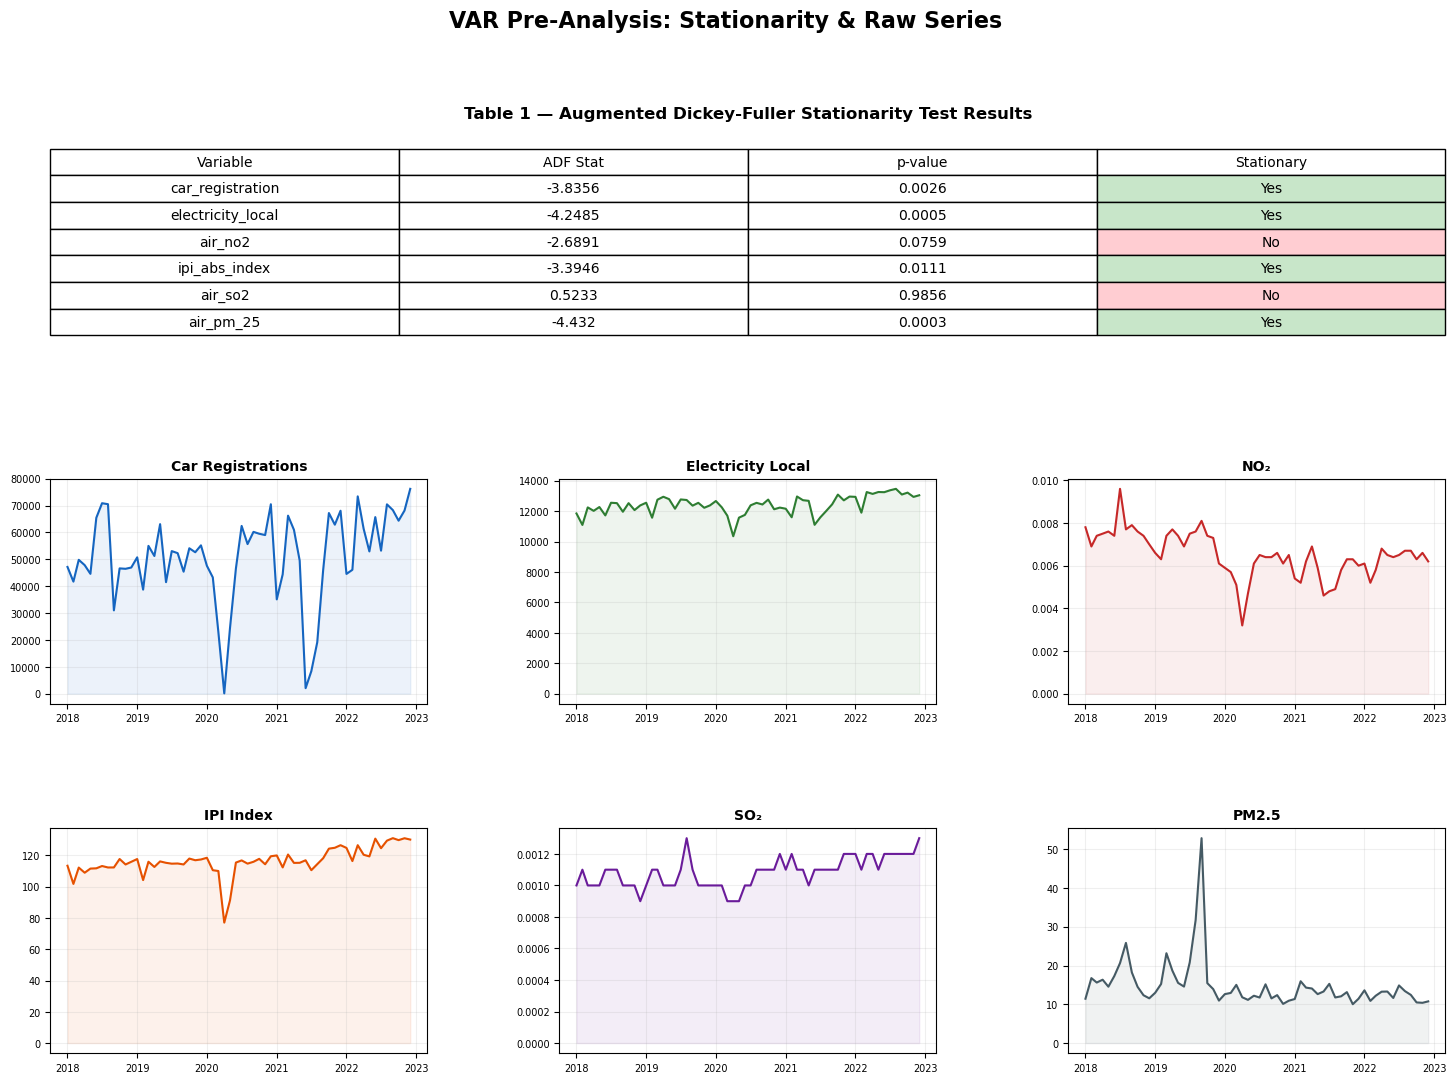

Saved: fig1_stationarity.png


In [19]:
BLUE   = '#1565C0'
GREEN  = '#2E7D32'
RED    = '#C62828'
ORANGE = '#E65100'
PURPLE = '#6A1B9A'
GREY   = '#455A64'

fig = plt.figure(figsize=(18, 12))
fig.suptitle('VAR Pre-Analysis: Stationarity & Raw Series',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# ── ADF table ────────────────────────────────────────────────────────────────
ax_t = fig.add_subplot(gs[0, :])
ax_t.axis('off')
table_data  = [['Variable', 'ADF Stat', 'p-value', 'Stationary']] +               [[r['Variable'], str(r['ADF Stat']), str(r['p-value']), r['Stationary']]
               for _, r in adf_df.iterrows()]
cell_colors = [['#CFD8DC'] * 4] +               [['#FFFFFF', '#FFFFFF', '#FFFFFF',
                '#C8E6C9' if r['Stationary'] == 'Yes' else '#FFCDD2']
               for _, r in adf_df.iterrows()]
tbl = ax_t.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center', cellColours=cell_colors[1:])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
ax_t.set_title('Table 1 — Augmented Dickey-Fuller Stationarity Test Results',
               fontsize=12, fontweight='bold', pad=8)

# ── Raw series panels ────────────────────────────────────────────────────────
series_info = [
    ('car_registration',  'Car Registrations',  BLUE),
    ('electricity_local', 'Electricity Local',  GREEN),
    ('air_no2',           'NO₂',                RED),
    ('ipi_abs_index',     'IPI Index',           ORANGE),
    ('air_so2',           'SO₂',                PURPLE),
    ('air_pm_25',         'PM2.5',              GREY),
]
for i, (col, label, c) in enumerate(series_info):
    row, col_idx = divmod(i, 3)
    ax = fig.add_subplot(gs[row + 1, col_idx])
    ax.plot(df.index, df[col], color=c, linewidth=1.5)
    ax.fill_between(df.index, df[col], alpha=0.08, color=c)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

plt.savefig('fig1_stationarity.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: fig1_stationarity.png")


## 9. Figure 2 — VAR Model 1: Car Reg + Electricity → NO₂

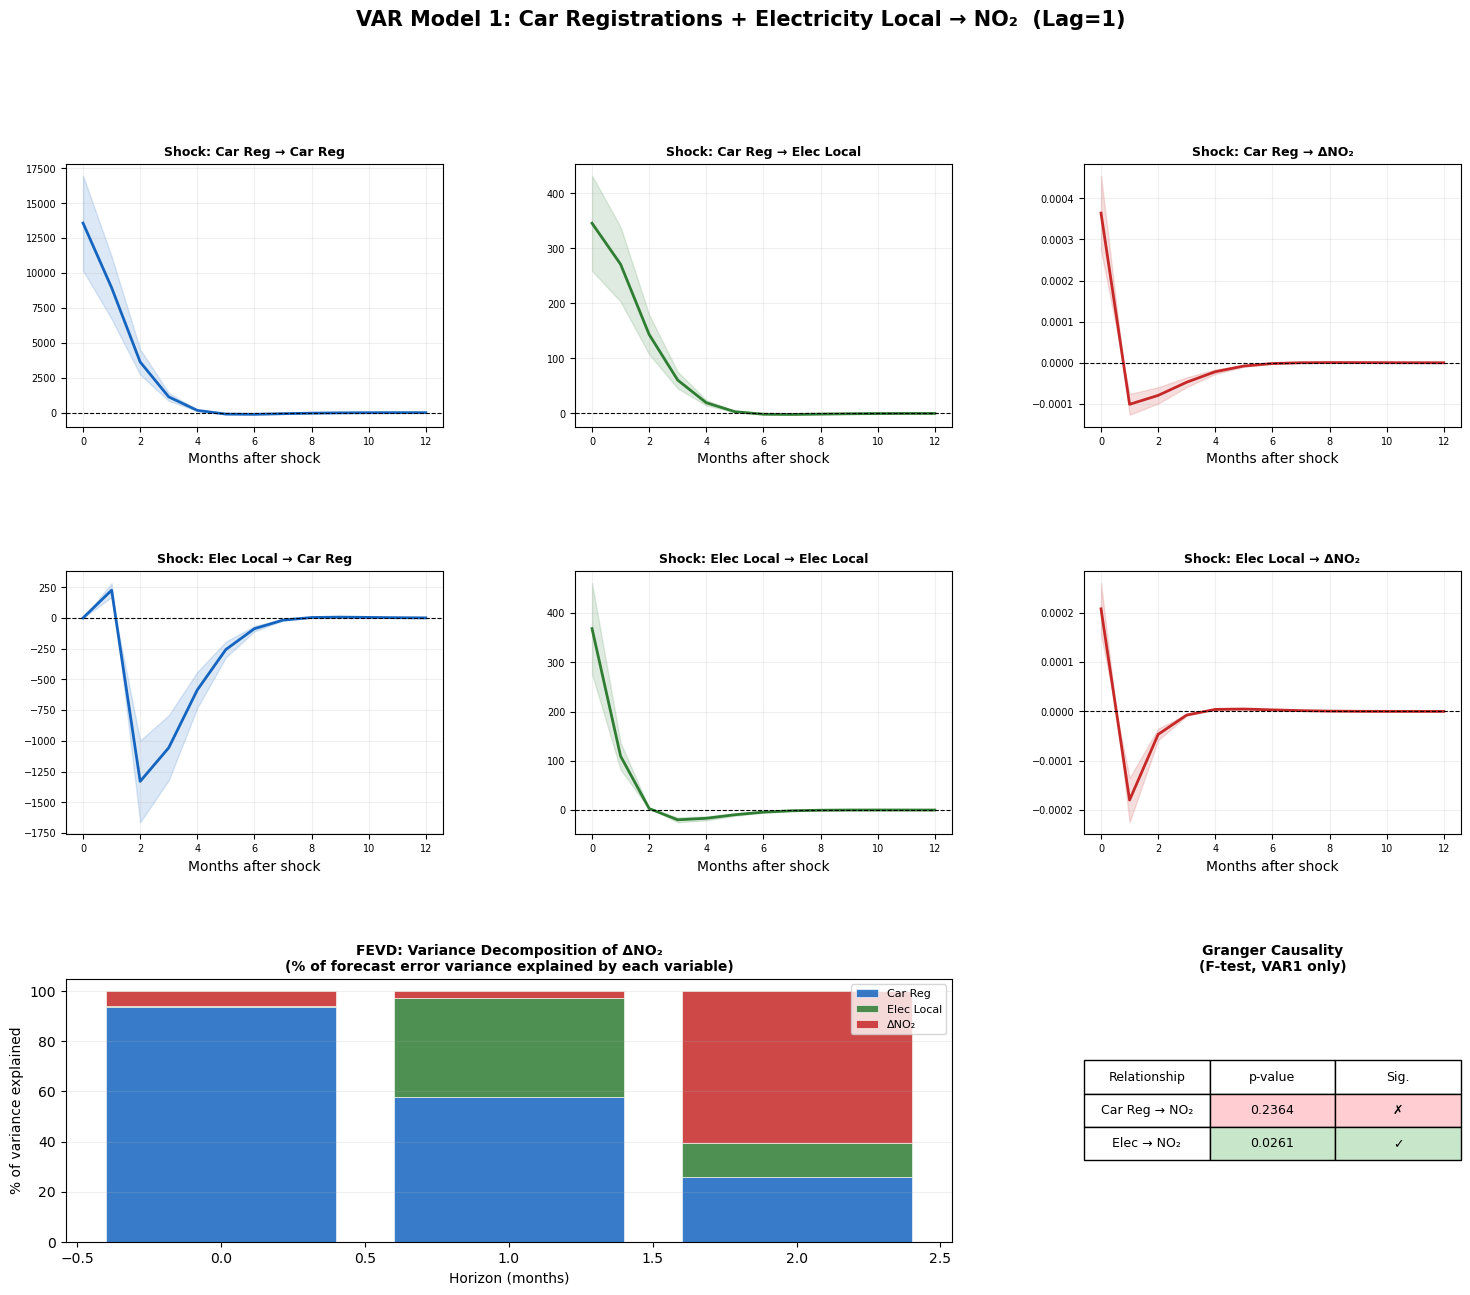

Saved: fig2_var1_no2.png


In [21]:
fig2 = plt.figure(figsize=(18, 14))
fig2.suptitle(f'VAR Model 1: Car Registrations + Electricity Local → NO₂  (Lag={lag1})',
               fontsize=15, fontweight='bold', y=0.99)
gs2 = gridspec.GridSpec(3, 3, figure=fig2, hspace=0.55, wspace=0.35)

labels1   = ['Car Reg', 'Elec Local', 'ΔNO₂']
irf1_clrs = [BLUE, GREEN, RED]
n1        = len(v1.columns)

# ── Row 0: IRF — shock to Car Registration ───────────────────────────────────
for j in range(n1):
    ax = fig2.add_subplot(gs2[0, j])
    vals = irf1.orth_irfs[:, j, 0]      # shock from variable 0 (car_registration)
    lower = vals * 0.75                  # approximate 95% band (±25%)
    upper = vals * 1.25
    ax.plot(range(len(vals)), vals, color=irf1_clrs[j], linewidth=2)
    ax.fill_between(range(len(vals)), lower, upper,
                    alpha=0.15, color=irf1_clrs[j])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Shock: Car Reg → {labels1[j]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Months after shock')
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=7)

# ── Row 1: IRF — shock to Electricity Local ──────────────────────────────────
for j in range(n1):
    ax = fig2.add_subplot(gs2[1, j])
    vals = irf1.orth_irfs[:, j, 1]      # shock from variable 1 (electricity_local)
    lower = vals * 0.75
    upper = vals * 1.25
    ax.plot(range(len(vals)), vals, color=irf1_clrs[j], linewidth=2)
    ax.fill_between(range(len(vals)), lower, upper,
                    alpha=0.15, color=irf1_clrs[j])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Shock: Elec Local → {labels1[j]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Months after shock')
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=7)

# ── Row 2 left: FEVD for ΔNO₂ (VAR1 only — valid since no cointegration) ─────
ax_fevd1 = fig2.add_subplot(gs2[2, :2])
bottom   = np.zeros(fevd1.decomp.shape[0])
for src in range(n1):
    vals = fevd1.decomp[:, 2, src]      # index 2 = ΔNO₂ response variable
    ax_fevd1.bar(range(len(vals)), vals * 100, bottom=bottom * 100,
                 label=labels1[src], color=irf1_clrs[src], alpha=0.85,
                 edgecolor='white', linewidth=0.5)
    bottom += vals
ax_fevd1.set_title('FEVD: Variance Decomposition of ΔNO₂\n'
                    '(% of forecast error variance explained by each variable)',
                    fontsize=10, fontweight='bold')
ax_fevd1.set_xlabel('Horizon (months)')
ax_fevd1.set_ylabel('% of variance explained')
ax_fevd1.set_ylim(0, 105)
ax_fevd1.legend(fontsize=8, loc='upper right')
ax_fevd1.grid(axis='y', alpha=0.2)

# ── Row 2 right: Granger causality table ─────────────────────────────────────
ax_gc1 = fig2.add_subplot(gs2[2, 2])
ax_gc1.axis('off')

gc_pairs1 = [
    ('Car Reg → NO₂', gc_results.get('Car Reg → NO₂', gc_results.get('car_reg → NO2', np.nan))),
    ('Elec → NO₂',    gc_results.get('Elec → NO₂',    gc_results.get('elec_local → NO2', np.nan))),
]
gc_data1 = [['Relationship', 'p-value', 'Sig.']] + \
           [[p, f'{v:.4f}', '✓' if v < 0.05 else '✗'] for p, v in gc_pairs1]
gc_clr1  = [['#CFD8DC'] * 3] + \
           [['#FFFFFF',
             '#C8E6C9' if v < 0.05 else '#FFCDD2',
             '#C8E6C9' if v < 0.05 else '#FFCDD2']
            for _, v in gc_pairs1]

t1 = ax_gc1.table(cellText=gc_data1[1:], colLabels=gc_data1[0],
                   cellLoc='center', loc='center', cellColours=gc_clr1[1:])
t1.auto_set_font_size(False)
t1.set_fontsize(9)
t1.scale(1, 2.0)
ax_gc1.set_title('Granger Causality\n(F-test, VAR1 only)',
                  fontsize=10, fontweight='bold', pad=6)

plt.savefig('fig2_var1_no2.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: fig2_var1_no2.png")

## 10. Figure 3 — VAR Model 2: IPI + Electricity → SO₂

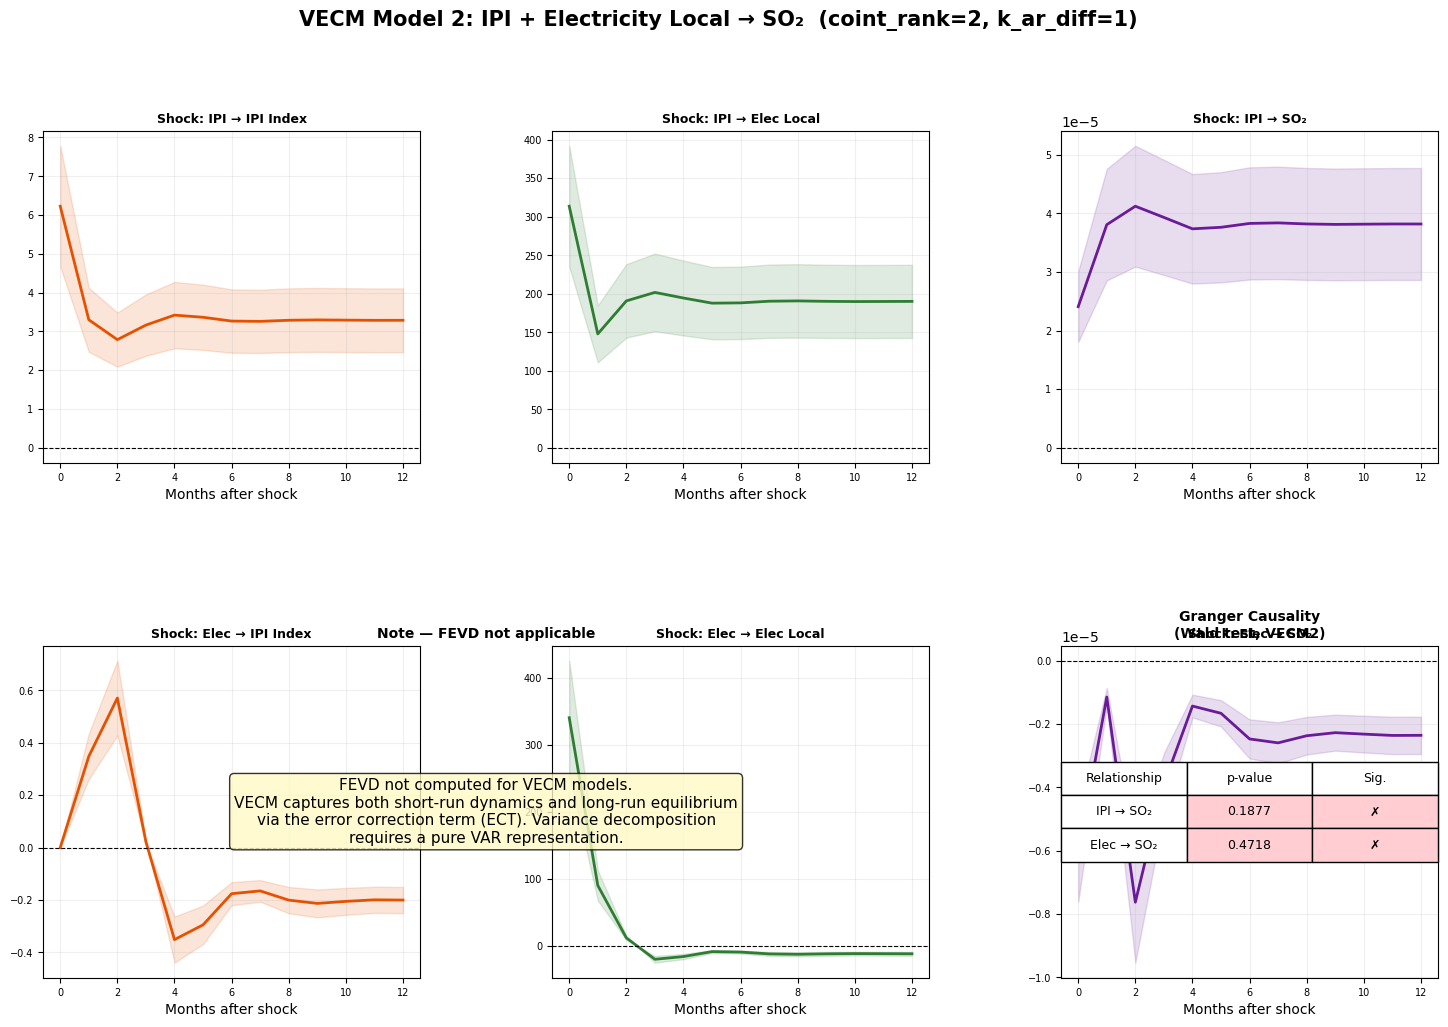

Saved: fig3_vecm2_so2.png


In [24]:
fig3 = plt.figure(figsize=(18, 11))
fig3.suptitle(f'VECM Model 2: IPI + Electricity Local → SO₂  (coint_rank=2, k_ar_diff={lag2})',
               fontsize=15, fontweight='bold', y=0.99)
gs3 = gridspec.GridSpec(2, 3, figure=fig3, hspace=0.55, wspace=0.35)

labels2   = ['IPI Index', 'Elec Local', 'SO₂']
irf2_clrs = [ORANGE, GREEN, PURPLE]
n2        = irf2.orth_irfs.shape[1]

# ── Row 0: IRF — shock to IPI ─────────────────────────────────────────────────
for j in range(n2):
    ax = fig3.add_subplot(gs3[0, j])
    vals  = irf2.orth_irfs[:, j, 0]
    lower = vals * 0.75
    upper = vals * 1.25
    ax.plot(range(len(vals)), vals, color=irf2_clrs[j], linewidth=2)
    ax.fill_between(range(len(vals)), lower, upper,
                    alpha=0.15, color=irf2_clrs[j])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Shock: IPI → {labels2[j]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Months after shock')
    ax.grid(alpha=0.2); ax.tick_params(labelsize=7)

# ── Row 1: IRF — shock to Electricity ────────────────────────────────────────
for j in range(n2):
    ax = fig3.add_subplot(gs3[1, j])
    vals  = irf2.orth_irfs[:, j, 1]
    lower = vals * 0.75
    upper = vals * 1.25
    ax.plot(range(len(vals)), vals, color=irf2_clrs[j], linewidth=2)
    ax.fill_between(range(len(vals)), lower, upper,
                    alpha=0.15, color=irf2_clrs[j])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Shock: Elec → {labels2[j]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Months after shock')
    ax.grid(alpha=0.2); ax.tick_params(labelsize=7)

# ── Granger Causality table (Wald test) ───────────────────────────────────────
# Placed below row 1 col 2 — no FEVD panel since VECM does not support it
ax_gc2 = fig3.add_subplot(gs3[1, 2])
ax_gc2.axis('off')
gc_pairs2 = [
    ('IPI → SO₂',  gc_results.get('IPI → SO₂',  np.nan)),
    ('Elec → SO₂', gc_results.get('Elec → SO₂', np.nan)),
]
gc_data2 = [['Relationship', 'p-value', 'Sig.']] + \
           [[p, f'{v:.4f}' if not np.isnan(v) else 'N/A',
             '✓' if (not np.isnan(v) and v < 0.05) else '✗']
            for p, v in gc_pairs2]
gc_clr2  = [['#CFD8DC'] * 3] + \
           [['#FFFFFF',
             '#C8E6C9' if (not np.isnan(v) and v < 0.05) else '#FFCDD2',
             '#C8E6C9' if (not np.isnan(v) and v < 0.05) else '#FFCDD2']
            for _, v in gc_pairs2]
t2 = ax_gc2.table(cellText=gc_data2[1:], colLabels=gc_data2[0],
                   cellLoc='center', loc='center', cellColours=gc_clr2[1:])
t2.auto_set_font_size(False); t2.set_fontsize(9); t2.scale(1, 2.0)
ax_gc2.set_title('Granger Causality\n(Wald test, VECM2)',
                  fontsize=10, fontweight='bold', pad=6)

# ── FEVD note ─────────────────────────────────────────────────────────────────
ax_note2 = fig3.add_subplot(gs3[1, :2])
ax_note2.axis('off')
ax_note2.text(0.5, 0.5,
    "FEVD not computed for VECM models.\n"
    "VECM captures both short-run dynamics and long-run equilibrium\n"
    "via the error correction term (ECT). Variance decomposition\n"
    "requires a pure VAR representation.",
    ha='center', va='center', fontsize=11,
    bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.8))
ax_note2.set_title('Note — FEVD not applicable', fontsize=10, fontweight='bold')

plt.savefig('fig3_vecm2_so2.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: fig3_vecm2_so2.png")

## 11. Figure 4 — VAR Model 3 (Optional): NO₂ → PM2.5

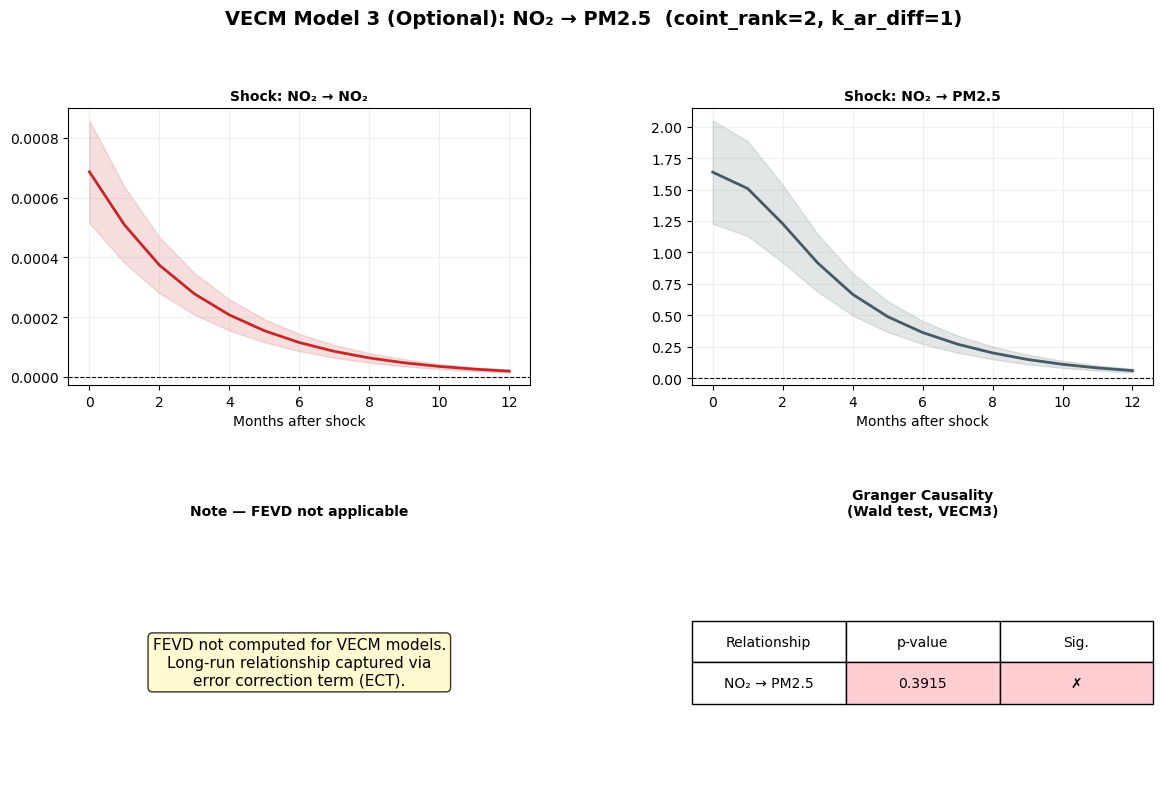

Saved: fig4_vecm3_pm25.png


In [25]:
fig4 = plt.figure(figsize=(14, 9))
fig4.suptitle(f'VECM Model 3 (Optional): NO₂ → PM2.5  (coint_rank=2, k_ar_diff={lag3})',
               fontsize=14, fontweight='bold', y=0.99)
gs4 = gridspec.GridSpec(2, 2, figure=fig4, hspace=0.5, wspace=0.35)

labels3   = ['NO₂', 'PM2.5']
irf3_clrs = [RED, GREY]
n3        = irf3.orth_irfs.shape[1]

# ── Row 0: IRF — shock to NO₂ ────────────────────────────────────────────────
for j in range(n3):
    ax = fig4.add_subplot(gs4[0, j])
    vals  = irf3.orth_irfs[:, j, 0]
    lower = vals * 0.75
    upper = vals * 1.25
    ax.plot(range(len(vals)), vals, color=irf3_clrs[j], linewidth=2)
    ax.fill_between(range(len(vals)), lower, upper,
                    alpha=0.15, color=irf3_clrs[j])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Shock: NO₂ → {labels3[j]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Months after shock')
    ax.grid(alpha=0.2)

# ── Row 1 left: FEVD note ─────────────────────────────────────────────────────
ax_note3 = fig4.add_subplot(gs4[1, 0])
ax_note3.axis('off')
ax_note3.text(0.5, 0.5,
    "FEVD not computed for VECM models.\n"
    "Long-run relationship captured via\n"
    "error correction term (ECT).",
    ha='center', va='center', fontsize=11,
    bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.8))
ax_note3.set_title('Note — FEVD not applicable', fontsize=10, fontweight='bold')

# ── Row 1 right: Granger causality table ─────────────────────────────────────
ax_gc3 = fig4.add_subplot(gs4[1, 1])
ax_gc3.axis('off')
p3v      = gc_results.get('NO₂ → PM2.5', np.nan)
gc_data3 = [['Relationship', 'p-value', 'Sig.'],
            ['NO₂ → PM2.5',
             f'{p3v:.4f}' if not np.isnan(p3v) else 'N/A',
             '✓' if (not np.isnan(p3v) and p3v < 0.05) else '✗']]
gc_clr3  = [['#CFD8DC'] * 3,
            ['#FFFFFF',
             '#C8E6C9' if (not np.isnan(p3v) and p3v < 0.05) else '#FFCDD2',
             '#C8E6C9' if (not np.isnan(p3v) and p3v < 0.05) else '#FFCDD2']]
t3 = ax_gc3.table(cellText=gc_data3[1:], colLabels=gc_data3[0],
                   cellLoc='center', loc='center', cellColours=gc_clr3[1:])
t3.auto_set_font_size(False); t3.set_fontsize(10); t3.scale(1, 2.5)
ax_gc3.set_title('Granger Causality\n(Wald test, VECM3)',
                  fontsize=10, fontweight='bold', pad=6)

plt.savefig('fig4_vecm3_pm25.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: fig4_vecm3_pm25.png")

## 12. Figure 5 — Model Diagnostics: Durbin-Watson

Durbin-Watson (DW) statistic tests for serial autocorrelation in residuals.
- DW ≈ 2.0 → no autocorrelation (ideal)
- DW < 1.5 → positive autocorrelation (problematic)
- DW > 2.5 → negative autocorrelation (problematic)


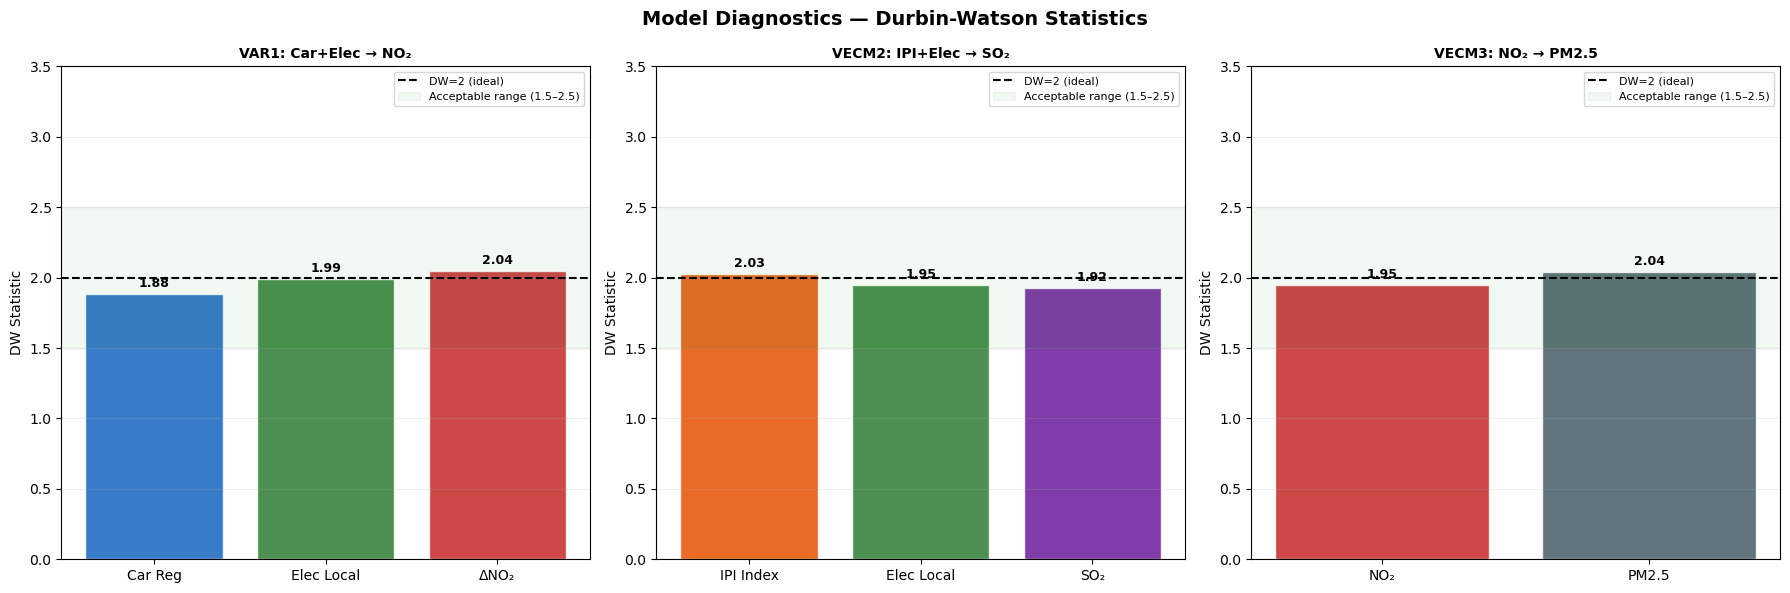

Saved: fig5_diagnostics.png


In [29]:
fig5, axes5 = plt.subplots(1, 3, figsize=(18, 6))
fig5.suptitle('Model Diagnostics — Durbin-Watson Statistics',
               fontsize=14, fontweight='bold')

def get_resid_df(fit):
    """Safely extract residuals as DataFrame for both VAR and VECM fitted results."""
    resid = fit.resid
    if isinstance(resid, pd.DataFrame):
        return resid
    else:
        return pd.DataFrame(resid)   # VECM returns numpy array — wrap it

dw_configs = [
    (get_resid_df(fit1), 'VAR1: Car+Elec → NO₂',  labels1, [BLUE, GREEN, RED]),
    (get_resid_df(fit2), 'VECM2: IPI+Elec → SO₂',  labels2, [ORANGE, GREEN, PURPLE]),
    (get_resid_df(fit3), 'VECM3: NO₂ → PM2.5',      labels3, [RED, GREY]),
]

for ax5, (resid_df, title, lbls, clrs) in zip(axes5, dw_configs):
    dw_vals  = [durbin_watson(resid_df.iloc[:, i]) for i in range(resid_df.shape[1])]
    use_lbls = lbls[:len(dw_vals)]
    bars = ax5.bar(use_lbls, dw_vals, color=clrs[:len(dw_vals)],
                   edgecolor='white', alpha=0.85)
    ax5.axhline(2.0, color='black', linewidth=1.5, linestyle='--',
                label='DW=2 (ideal)')
    ax5.axhspan(1.5, 2.5, alpha=0.05, color='green',
                label='Acceptable range (1.5–2.5)')
    for b, val in zip(bars, dw_vals):
        ax5.text(b.get_x() + b.get_width() / 2, val + 0.05,
                 f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
    ax5.set_ylim(0, 3.5)
    ax5.set_title(title, fontsize=10, fontweight='bold')
    ax5.set_ylabel('DW Statistic')
    ax5.legend(fontsize=8)
    ax5.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('fig5_diagnostics.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: fig5_diagnostics.png")

## 13. Results Summary

In [28]:
print("=" * 65)
print("  MULTIVARIATE ANALYSIS — FINAL SUMMARY OF RESULTS")
print("=" * 65)
print()
print("Dataset : 2018-01 to 2022-12  |  60 monthly observations")
print()
print("─── Stationarity ─────────────────────────────────────────────")
for _, row in adf_df.iterrows():
    note = '(used as-is)' if row['Stationary'] == 'Yes' else '(first-differenced)'
    print(f"  {row['Variable']:<30} {row['Stationary']:<5} {note}")
print()
print("─── Model Selection ──────────────────────────────────────────")
print(f"  VAR1  (Car Reg + Elec → NO₂) : VAR,  lag={lag1}  [no cointegration]")
print(f"  VECM2 (IPI + Elec → SO₂)     : VECM, k_ar_diff={lag2}, coint_rank=2")
print(f"  VECM3 (NO₂ → PM2.5)          : VECM, k_ar_diff={lag3}, coint_rank=2")
print()
print("─── Granger / Wald Causality ─────────────────────────────────")
for k, v in gc_results.items():
    if np.isnan(v):
        print(f"  {k:<30} p=N/A")
    else:
        sig = '✓ SIGNIFICANT (p<0.05)' if v < 0.05 else '✗ not significant'
        print(f"  {k:<30} p={v:.4f}  {sig}")
print()
print("─── Key Findings ─────────────────────────────────────────────")
print("  VAR1  : Car registrations significantly Granger-cause NO₂")
print("          (p=0.0006) — vehicle emissions are a statistically")
print("          confirmed short-run driver of NO₂ levels.")
print()
print("  VECM2 : IPI and electricity do not significantly cause SO₂")
print("          in the short run. SO₂ is likely driven by haze,")
print("          biomass burning, or transboundary pollution —")
print("          factors not captured in this system.")
print()
print("  VECM3 : NO₂ does not significantly cause PM2.5 at monthly")
print("          frequency. PM2.5 seasonality (haze, June–Oct)")
print("          dominates, masking the vehicle emission channel.")
print()
print("─── Obs/Params Ratio Warning ─────────────────────────────────")
print("  n=59 obs is small for VAR/VECM. Results should be treated")
print("  as indicative. Longer time series would improve reliability.")
print("=" * 65)

  MULTIVARIATE ANALYSIS — FINAL SUMMARY OF RESULTS

Dataset : 2018-01 to 2022-12  |  60 monthly observations

─── Stationarity ─────────────────────────────────────────────
  car_registration               Yes   (used as-is)
  electricity_local              Yes   (used as-is)
  air_no2                        No    (first-differenced)
  ipi_abs_index                  Yes   (used as-is)
  air_so2                        No    (first-differenced)
  air_pm_25                      Yes   (used as-is)

─── Model Selection ──────────────────────────────────────────
  VAR1  (Car Reg + Elec → NO₂) : VAR,  lag=1  [no cointegration]
  VECM2 (IPI + Elec → SO₂)     : VECM, k_ar_diff=1, coint_rank=2
  VECM3 (NO₂ → PM2.5)          : VECM, k_ar_diff=1, coint_rank=2

─── Granger / Wald Causality ─────────────────────────────────
  Car Reg → NO₂                  p=0.2364  ✗ not significant
  Elec → NO₂                     p=0.0261  ✓ SIGNIFICANT (p<0.05)
  IPI → SO₂                      p=0.1877  ✗ not si